# Early stopping

In [1]:
from sklearn.datasets import make_moons
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score


###### Tensorflow-GPU ########
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if physical_devices:  # Check if the list is not empty
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No GPU devices found.")

import re



No GPU devices found.


In [2]:
tf.config.experimental.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## Dataset creation

In [2]:
# Dataset generation
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)

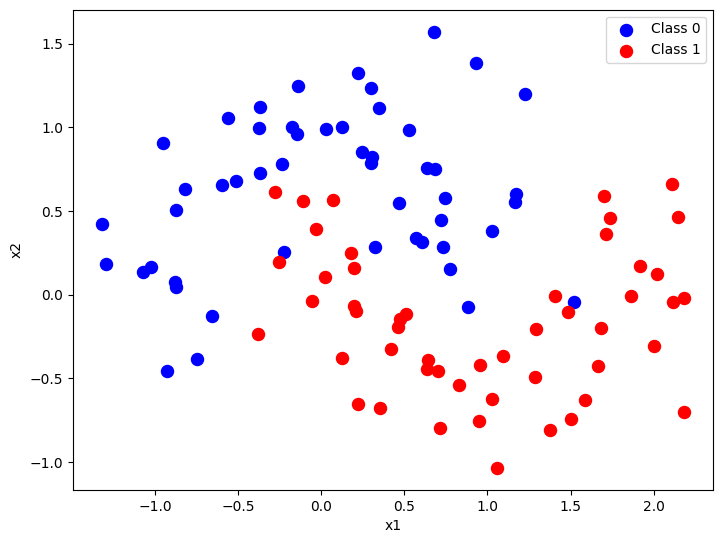

In [3]:
x1 = X[:,0]
x2 = X[:,1]

zero_class = (y ==0)
one_class =  (y==1)

fig_admission = plt.figure()
ax_admission = fig_admission.add_axes([0,0,1,1])
ax_admission.scatter(x1[zero_class],x2[zero_class], c='b', s=75, label='Class 0')
ax_admission.scatter(x1[one_class], x2[one_class], c='r',s=75, label='Class 1')
ax_admission.set_xlabel('x1')
ax_admission.set_ylabel('x2')
ax_admission.legend(loc=1,numpoints=1)

In [4]:
# Training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state =0)

## Neural network training and testing

In [5]:
# Neural network

model = Sequential()
model.add(Dense(200, input_dim=2, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Training
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, verbose=1)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4642 - loss: 0.6847 - val_accuracy: 0.7333 - val_loss: 0.6415
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7920 - loss: 0.6073 - val_accuracy: 0.7333 - val_loss: 0.5936
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7685 - loss: 0.5462 - val_accuracy: 0.8000 - val_loss: 0.5335
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7640 - loss: 0.4899 - val_accuracy: 0.8000 - val_loss: 0.4686
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8062 - loss: 0.4309 - val_accuracy: 0.8333 - val_loss: 0.4081
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8056 - loss: 0.3824 - val_accuracy: 0.8667 - val_loss: 0.3662
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8134 - loss: 0.3482 - val_accuracy: 0.8667 - val_loss: 0.3379
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8511 - loss: 0.3316 - val_accuracy: 0.8667 - v

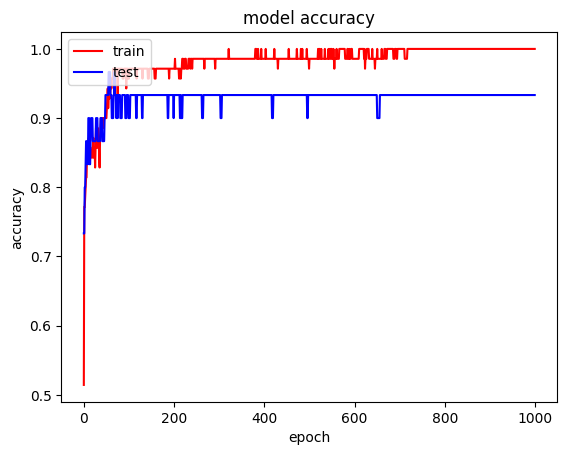

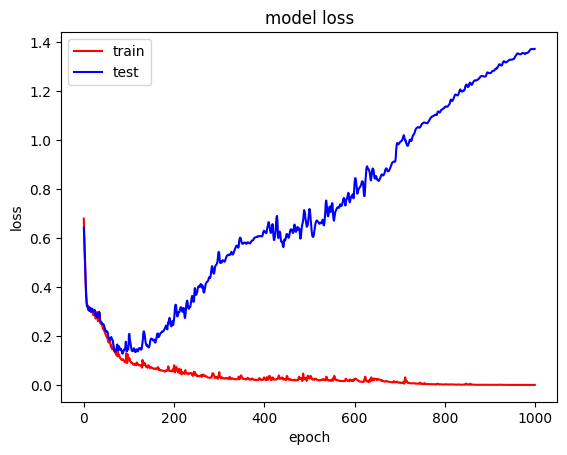

In [7]:
# Plot history

# Accuray 
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# Loss 
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Early stopping

In [8]:
# Import EarlyStopping for stopping training when validation loss stops improving
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
# Monitors the validation loss ('val_loss') and stops training when it stops decreasing
# 'mode' is set to 'min' because we want to minimize the validation loss
# 'verbose=1' enables logging when early stopping is triggered
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1)

# Define a Sequential neural network model
model = Sequential()

# Input layer with 2 input features and 200 neurons, using ReLU activation
model.add(Dense(200, input_dim=2, activation='relu'))

# Hidden layer with 200 neurons and ReLU activation
model.add(Dense(200, activation='relu'))

# Another hidden layer with 200 neurons and ReLU activation
model.add(Dense(200, activation='relu'))

# Output layer with 1 neuron and sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
# Loss function: Binary cross-entropy for binary classification
# Optimizer: Adam optimizer for adaptive learning rate
# Metrics: Accuracy to evaluate model performance
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
# Training data: X_train and y_train
# Validation data: X_test and y_test
# Epochs: Maximum of 1000 epochs
# Verbose: 1 (displays training progress)
# Callbacks: Early stopping to stop training when validation loss stops improving
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, verbose=1, callbacks=[es])

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7835 - loss: 0.6650 - val_accuracy: 0.8333 - val_loss: 0.6213
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8023 - loss: 0.5931 - val_accuracy: 0.8000 - val_loss: 0.5585
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7750 - loss: 0.5289 - val_accuracy: 0.8000 - val_loss: 0.4900
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8056 - loss: 0.4589 - val_accuracy: 0.8000 - val_loss: 0.4302
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7984 - loss: 0.4070 - val_accuracy: 0.8000 - val_loss: 0.3797
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8141 - loss: 0.3684 - val_accuracy: 0.8333 - val_loss: 0.3420
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8212 - loss: 0.3398 - val_accuracy: 0.8667 - val_loss: 0.3214
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8316 - loss: 0.3509 - val_accuracy: 0.8333 - v

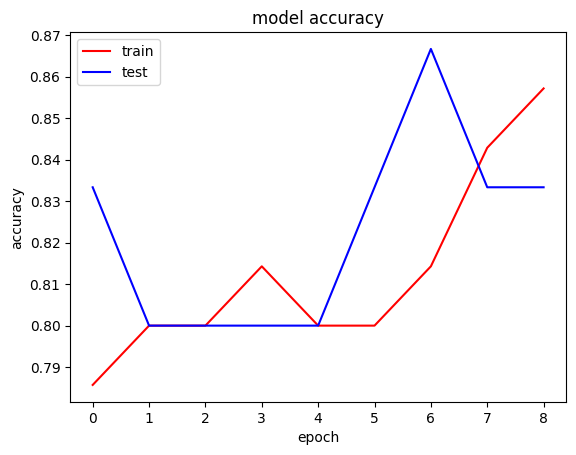

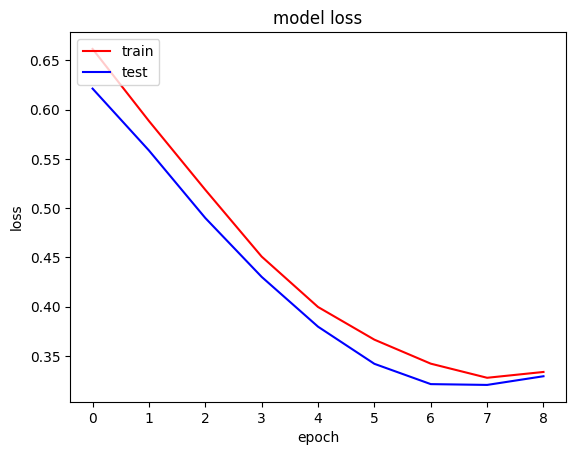

In [9]:
# Plot history

# Accuray 
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# Loss 
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Early stopping with patience

In [10]:
# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience = 20)

# Neural netwok with early stopping

model = Sequential()
model.add(Dense(200, input_dim=2, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000,verbose=1,callbacks=[es])

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6475 - loss: 0.6766 - val_accuracy: 0.8333 - val_loss: 0.6221
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7893 - loss: 0.6080 - val_accuracy: 0.8667 - val_loss: 0.5614
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8017 - loss: 0.5375 - val_accuracy: 0.8333 - val_loss: 0.4984
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7743 - loss: 0.4866 - val_accuracy: 0.8333 - val_loss: 0.4353
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8173 - loss: 0.4040 - val_accuracy: 0.8667 - val_loss: 0.3822
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8329 - loss: 0.3356 - val_accuracy: 0.8667 - val_loss: 0.3503
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8511 - loss: 0.3310 - val_accuracy: 0.8667 - val_loss: 0.3348
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8732 - loss: 0.3227 - val_accuracy: 0.8333 - v

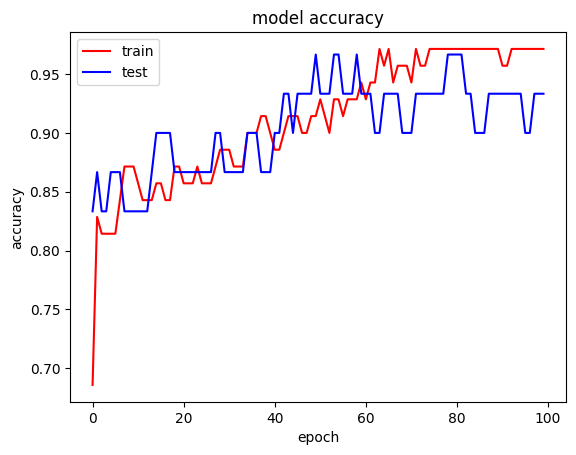

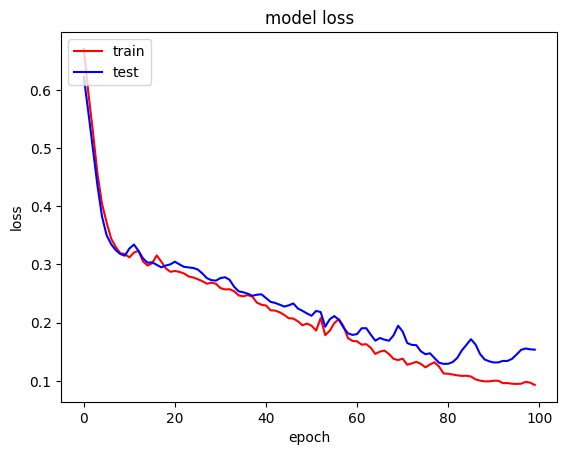

In [11]:
# Plot history

# Accuray 
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# Loss 
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## Early stopping with patience and Modelcheckpoint saving

In [14]:
# Import necessary callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Must end with .weights.h5 when save_weights_only=True
checkpoint_filepath = './best_model.weights.h5'

mc = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=20,
    verbose=1
)

model = Sequential()
model.add(Dense(200, input_dim=2, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

story = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    verbose=1,
    callbacks=[es, mc]
)


Epoch 1/200
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5312 - loss: 0.6820
Epoch 1: val_accuracy improved from -inf to 0.83333, saving model to ./best_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6397 - loss: 0.6691 - val_accuracy: 0.8333 - val_loss: 0.6160
Epoch 2/200
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7812 - loss: 0.5966
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7835 - loss: 0.5833 - val_accuracy: 0.8000 - val_loss: 0.5513
Epoch 3/200
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8125 - loss: 0.5329
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8062 - loss: 0.5134 - val_accuracy: 0.8333 - val_loss: 0.4852
Epoch 4/200
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8438 - loss: 0.4232
Epoch 4: val_accuracy improved from 0.83333 to 0.86667, saving model to ./best_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20m

In [15]:
# Loading the best performing model
model.load_weights(checkpoint_filepath)

# Testing the best performing model
y_pred = (model.predict(X_test) > 0.5).astype('int32')

print('\n')
print(classification_report(y_test, y_pred))

cf = confusion_matrix(y_test, y_pred)

print(cf)
print(accuracy_score(y_test, y_pred) * 100) 




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.93      1.00      0.97        14

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

[[15  1]
 [ 0 14]]
96.66666666666667
